# Lab 3 — Transfer learning on a dataset of your own

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kleinric/cv-labs/blob/main/lab-03.ipynb)

**COMS4036A / COMS7050A Computer Vision · Week 3**

**Due: Thursday 13 August 2026, 17:00.** Groups of up to three; one member submits the group's notebook (`.ipynb`) on Moodle. Every member must be able to explain every cell.

Companion reading is [Chapter 3 of the course book](https://courses.ms.wits.ac.za/~richard/cv/book/chapters/03-architectures-transfer.html). Lab 2 trained a small network from scratch on CIFAR-10, where the book's reference run reaches 77% validation accuracy after forty epochs. This lab classifies 37 cat and dog breeds, a harder problem with about a hundred training photographs per class where CIFAR-10 gave five thousand, and gets past 90% in six epochs. This week's network is the bigger one, but Section 6's control shows that is not where the difference lives. What changed is where the weights started.

Two rungs of the skills ladder are marked this week: a **`Dataset` you write yourself**, from a directory of files and a text file of labels, and an **augmentation pipeline you look at before you train on it**.

The Friday session covers Sections 0–4; Sections 5–8 are the take-home half.

## 0. GPU, W&B, and the data

Open this notebook in [Colab](https://colab.research.google.com) with the badge above, then **File ▸ Save a copy in Drive**. Set **Runtime ▸ Change runtime type** to a GPU as in Lab 2, and log in to W&B; this lab logs to a project called `cv-lab3`.

In [25]:
# Group members — fill in before submitting.
MEMBERS = [
    # ("Student name", "Student number"),
    ( "2539199", "Nkosenhle Ndlovu" )
]
for name, number in MEMBERS:
    print(f"{number}  {name}")

Nkosenhle Ndlovu  2539199


In [26]:
!nvidia-smi --query-gpu=name,memory.total --format=csv

name, memory.total [MiB]
Tesla T4, 15360 MiB


In [27]:
!pip install wandb

In [28]:
import wandb
wandb.login()

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


False

The dataset is the [Oxford-IIIT Pet dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/) (Parkhi et al., 2012): 37 breeds of cat and dog, roughly 200 photographs each, with an official train/test split. It is licensed CC BY-SA 4.0. Two archives, about 800 MB together; the download takes a minute or two.

In [29]:
!wget -q -nc https://thor.robots.ox.ac.uk/pets/images.tar.gz
!wget -q -nc https://thor.robots.ox.ac.uk/pets/annotations.tar.gz
!tar -xzf images.tar.gz && tar -xzf annotations.tar.gz
!ls annotations | head && head -3 annotations/trainval.txt

list.txt
README
test.txt
trainval.txt
trimaps
xmls
Abyssinian_100 1 1 1
Abyssinian_101 1 1 1
Abyssinian_102 1 1 1


In [30]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from torchvision.models import ResNet50_Weights, resnet50

DEV = "cuda" if torch.cuda.is_available() else "cpu"


def seed_everything(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(0)
print("device:", DEV)

device: cuda


## 1. A `Dataset` of your own

Lab 2's data arrived as `datasets.CIFAR10(...)`: one line, already split, already labelled. Real data does not. Here you have a directory of JPEGs and a text file, and the job of turning them into something a `DataLoader` can shuffle is yours.

`annotations/trainval.txt` and `annotations/test.txt` have one line per image:

```
Abyssinian_100 1 1 1
```

The fields are the image's file stem, its class ID from 1 to 37, its species (1 cat, 2 dog), and a breed ID within the species. Only the first two matter here. The breed name is in the stem: strip the trailing `_100`.

Three things about this directory will break a naive implementation, and all three are ordinary:

- `images/` holds a few `.mat` files as well as `.jpg`, and it holds 41 more photographs than the two split files list. Read the split file; do not list the directory.
- Three of the listed JPEGs decode to RGBA rather than RGB. `Image.open(...).convert("RGB")` fixes them, and without it your batches will fail to stack part-way through a run rather than at the start of one.
- Opening every image in `__init__` would exhaust Colab's memory. `__init__` reads the *list*; `__getitem__` reads the *image*.

**Q1.1.** Implement `PetsDataset`. `__init__` takes the split name and a transform and builds two parallel lists, of file stems and of integer labels in $[0, 37)$, plus `self.classes`, the 37 breed names in class-ID order. `__len__` returns the number of images; `__getitem__(i)` opens image $i$, converts it to RGB, applies the transform, and returns `(image, label)`.

In [31]:
from pathlib import Path

# Colab extracts the two archives into the working directory; the fallback lets
# the same notebook run against a local copy of the data.
ROOT = Path("data-files/lab-03") if Path("data-files/lab-03/images").is_dir() else Path(".")
print("data root:", ROOT.resolve())


class PetsDataset(Dataset):
    """Oxford-IIIT Pets, driven by the split file rather than by listing images/.

    __init__ reads the *list* (3,680 strings); __getitem__ reads the *image*, so
    Colab's memory never holds thousands of decoded photographs at once.
    """

    def __init__(self, split, transform=None, root=ROOT):
        self.root = Path(root)
        self.split = split
        self.transform = transform
        self.stems, self.labels = [], []

        with open(self.root / "annotations" / f"{split}.txt") as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith("#"):
                    continue
                stem, class_id = line.split()[:2]  # species and breed id unused
                self.stems.append(stem)
                self.labels.append(int(class_id) - 1)  # 1..37 -> 0..36

        # the breed name is the stem with its trailing _<number> stripped
        names = {}
        for stem, label in zip(self.stems, self.labels):
            names[label] = stem.rsplit("_", 1)[0]
        self.classes = [names[i] for i in sorted(names)]  # in class-ID order

    def __len__(self):
        return len(self.stems)

    def __getitem__(self, i):
        path = self.root / "images" / f"{self.stems[i]}.jpg"
        img = Image.open(path).convert("RGB")  # three of these decode to RGBA
        if self.transform is not None:
            img = self.transform(img)
        return img, self.labels[i]

data root: /content


**Q1.2.** Build the two splits with `transform=None` for now and check them: how many images in each, how many classes, and the smallest and largest number of images any class has in the training split? Print `train_set.classes[:5]`. `wc -l annotations/trainval.txt annotations/test.txt` gives the counts your parser must reproduce; if yours disagree, your parser is wrong, not the dataset.

In [32]:
# YOUR CODE HERE
from collections import Counter

train_set = PetsDataset("trainval", transform=None)
test_set = PetsDataset("test", transform=None)

counts = Counter(train_set.labels)
print(f"trainval images : {len(train_set)}")
print(f"test images     : {len(test_set)}")
print(f"classes         : {len(train_set.classes)}")
print(f"trainval per class: min {min(counts.values())}, max {max(counts.values())}")
print("first five classes:", train_set.classes[:5])

# the counts the parser has to reproduce
!wc -l {ROOT}/annotations/trainval.txt {ROOT}/annotations/test.txt

# images/ holds more than the splits list, which is why we read the split file
jpgs = list((ROOT / "images").glob("*.jpg"))
print(f"\nJPEGs on disk {len(jpgs)}, listed by the two splits "
      f"{len(train_set) + len(test_set)}, difference "
      f"{len(jpgs) - len(train_set) - len(test_set)}")

# and the RGBA files the naive implementation trips over (header read, not pixels)
odd = [s for s in train_set.stems + test_set.stems
       if Image.open(ROOT / "images" / f"{s}.jpg").mode != "RGB"]
print("listed JPEGs that are not RGB:", odd)

trainval images : 3680
test images     : 3669
classes         : 37
trainval per class: min 93, max 100
first five classes: ['Abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle']
  3680 ./annotations/trainval.txt
  3669 ./annotations/test.txt
  7349 total

JPEGs on disk 7390, listed by the two splits 7349, difference 41
listed JPEGs that are not RGB: ['Egyptian_Mau_14', 'Egyptian_Mau_186', 'Abyssinian_5']


*Answer:* 3,680 training images and 3,669 test images, 7,349 in total, which is exactly what `wc -l` reports on the two split files. There are 37 classes. The training split is close to balanced but not exactly: every class has between 93 and 100 images. `train_set.classes[:5]` is `['Abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle']` — the class IDs run in case-insensitive alphabetical order over the breed names, so cats (capitalised) and dogs (lower case) are interleaved rather than grouped.

The directory holds 7,390 JPEGs, 41 more than the splits list, plus a handful of `.mat` files; and three of the listed JPEGs (`Abyssinian_5`, `Egyptian_Mau_14`, `Egyptian_Mau_186`) are RGBA. Both are the reasons for reading the split file and for `.convert("RGB")`.

**Q1.3.** Display one photograph per class in a $5 \times 8$ grid, titled with the breed name. Look at them. Which pairs of breeds do you expect the network to confuse, and why?

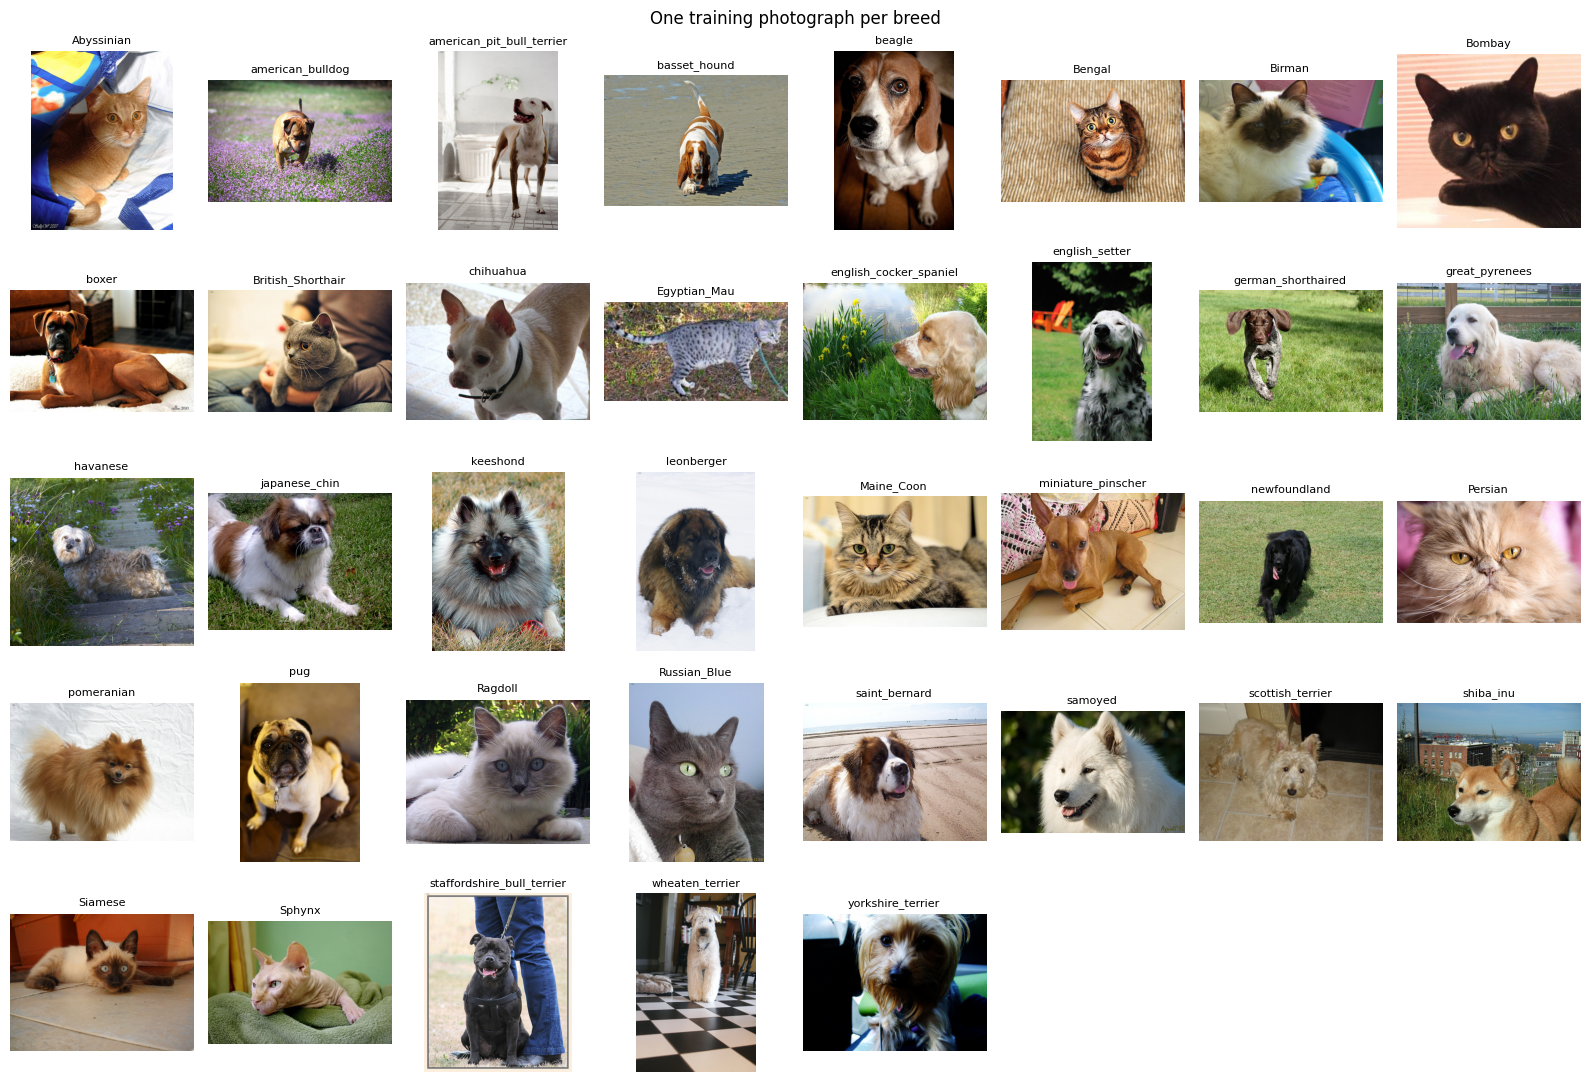

In [33]:
# YOUR CODE HERE
first = {}
for i, label in enumerate(train_set.labels):
    first.setdefault(label, i)  # first training image of each class

fig, axes = plt.subplots(5, 8, figsize=(16, 11))
for cls, ax in enumerate(axes.flat):
    if cls >= len(train_set.classes):
        ax.axis("off")  # 40 panels, 37 breeds
        continue
    img, _ = train_set[first[cls]]  # transform is None, so this is a PIL image
    ax.imshow(img)
    ax.set_title(train_set.classes[cls], fontsize=8)
    ax.axis("off")

fig.suptitle("One training photograph per breed")
plt.tight_layout()
plt.show()

*Answer:* The pairs I expect to be confused are the ones where the breeds differ by coat texture and head proportion rather than by silhouette, because within a breed the variation in pose, scale and lighting is far larger than the between-breed difference:

- `american_pit_bull_terrier` / `staffordshire_bull_terrier` / `american_bulldog` — the same short-coated molosser build; even a human judge often separates these by pedigree rather than by photograph.
- `Bengal` / `Egyptian_Mau` / `Abyssinian` — spotted or ticked brown tabby cats. Bengal and Egyptian Mau are both spotted; the difference is the shape of the rosettes.
- `Birman` / `Ragdoll` / `Siamese` — colourpoint cats with pale bodies, dark masks and blue eyes. Birman and Ragdoll are essentially the same pattern at different sizes.
- `Maine_Coon` / `Persian` / `Ragdoll` — long-haired cats whose distinguishing cue is muzzle length, which a random crop can easily throw away.
- `great_pyrenees` / `samoyed` — large white double-coated dogs.
- `english_setter` / `english_cocker_spaniel` — drop ears and the same roan/ticked coats.
- `chihuahua` / `miniature_pinscher` — small, tan, prick-eared, and photographed at the same close range.
- `havanese` / `wheaten_terrier` — shaggy cream coats.

The common thread is that the discriminating information is fine-grained and local (fur texture, muzzle length, ear set), which is exactly the regime where a general-purpose ImageNet representation helps and where a low-resolution crop hurts.

## 2. Augmentation, seen before it is trained on

Two transform pipelines, doing different jobs. The evaluation pipeline is fixed: resize the short side to 256, take the centre $224 \times 224$ crop, and normalise with **ImageNet's** channel statistics, the ones the pretrained weights were fitted against. The training pipeline adds the randomness: a random resized crop and a horizontal flip, so the network sees a slightly different photograph of the same animal at every epoch.

**Q2.1.** Build `eval_tf` and `train_tf` as described (`transforms.RandomResizedCrop(224, scale=(0.6, 1.0))`, `RandomHorizontalFlip`, `ToTensor`, and the normalisation with mean `(0.485, 0.456, 0.406)` and standard deviation `(0.229, 0.224, 0.225)`). Rebuild both datasets with them, and build a training loader with `batch_size=32, shuffle=True, num_workers=2` and a test loader with `batch_size=64`.

In [34]:
# YOUR CODE HERE
# ImageNet's channel statistics: the numbers the pretrained weights were fitted
# against, not this dataset's own (see Q2.4).
norm = transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))

eval_tf = transforms.Compose([
    transforms.Resize(256),  # short side to 256, aspect ratio kept
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    norm,
])

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    norm,
])

train_set = PetsDataset("trainval", transform=train_tf)
test_set = PetsDataset("test", transform=eval_tf)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_set, batch_size=64, num_workers=2)

print(f"{len(train_set)} train / {len(test_set)} test images")
print(f"{len(train_loader)} training batches of 32, "
      f"{len(test_loader)} test batches of 64")
x, y = train_set[0]
print("one training example:", tuple(x.shape), "label", y, train_set.classes[y])

3680 train / 3669 test images
115 training batches of 32, 58 test batches of 64
one training example: (3, 224, 224) label 0 Abyssinian


**Q2.2.** Now look at what you just built. Take one training batch and display its first twelve images, un-normalised for display (multiply by the standard deviation, add the mean, clip to $[0,1]$). Run the cell twice. This is the week's second rung: if a crop has cut the animal's head off, or the colours are wrong, or the image is upside down, you find out now rather than after an hour of training.

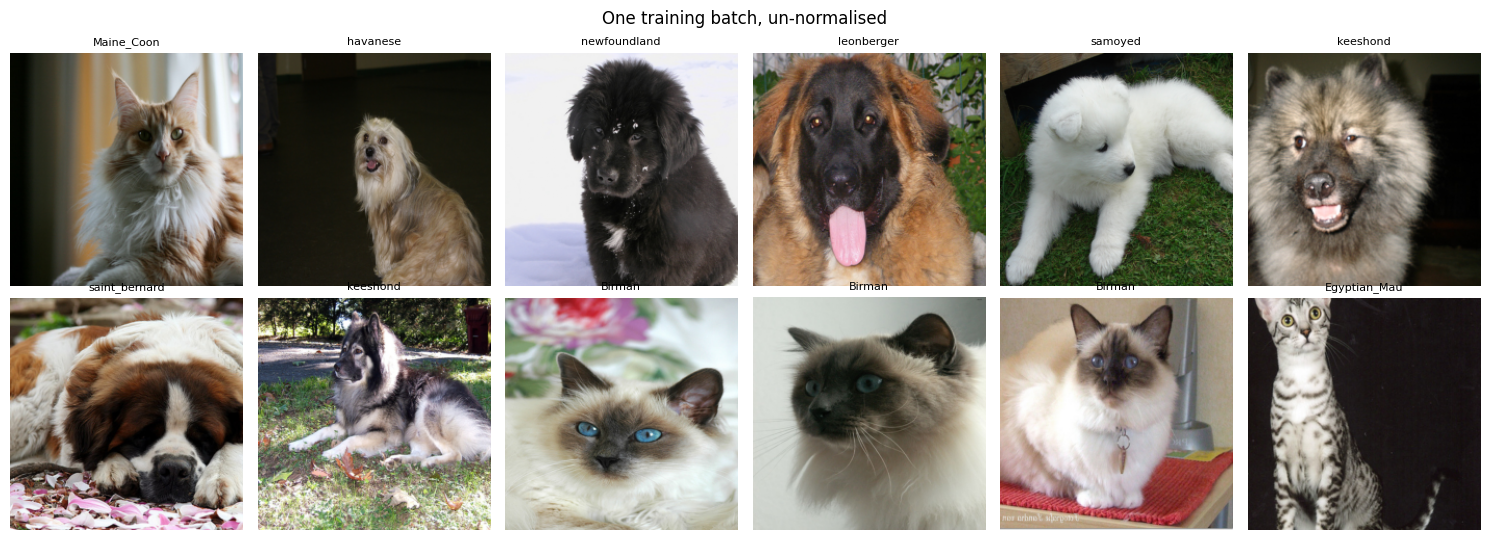

In [35]:
# YOUR CODE HERE
# Run this cell twice: the crops and flips are redrawn, the photographs are not.
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


def show_batch(xb, yb, classes, n=12, title="One training batch, un-normalised"):
    fig, axes = plt.subplots(2, 6, figsize=(15, 5.5))
    for i, ax in enumerate(axes.flat[:n]):
        img = (xb[i] * STD + MEAN).clamp(0, 1)  # undo the normalisation
        ax.imshow(img.permute(1, 2, 0).numpy())  # CHW -> HWC for imshow
        ax.set_title(classes[yb[i]], fontsize=8)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


xb, yb = next(iter(train_loader))
show_batch(xb, yb, train_set.classes)

**Q2.3.** Two augmentations you were *not* given: `RandomVerticalFlip` and `RandomRotation(180)`. For each, say whether you would include it here and why. Then name one augmentation that would be sensible for these photographs and is not in the list above.

*Answer:*

**`RandomVerticalFlip` — no.** An augmentation asserts an invariance that holds in the data. Horizontal flipping is safe because a cat facing left and a cat facing right are both ordinary photographs, and both occur at test time. Upside-down pets do not: every image in this dataset was taken by a person holding a camera the right way up, so vertical flipping generates inputs from a distribution the test set never draws from. The network would spend capacity learning to be invariant to something it is never asked about, and it destroys the vertical arrangement (ears above eyes above muzzle) that carries much of the breed signal.

**`RandomRotation(180)` — no**, for the same reason and one more. Rotations of up to $\pm180°$ are the vertical flip's problem in continuous form, and they also pad the corners with a constant fill after rotation, so every rotated image carries a black wedge that the network can learn to key on. A *small* rotation, `RandomRotation(15)`, would be reasonable: hand-held snapshots genuinely are a few degrees off level, so that invariance really is in the data.

**One I would add: `ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.02)`.** These photographs vary a lot in lighting and white balance, so brightness, contrast and saturation jitter matches real variation. Hue is the one to keep tiny — coat colour genuinely separates, say, `Bombay` from `British_Shorthair`, so shifting hue hard would destroy label information rather than add invariance. (`RandomErasing`, for robustness to occlusion by furniture and hands, would be the next choice.)

**Q2.4.** The normalisation numbers above are ImageNet's, not this dataset's. Compute the Pet training set's own channel means and standard deviations (a few hundred images is enough for two decimal places; say so if you subsample). Report both triples. Then answer: why does the pretrained backbone want ImageNet's numbers rather than the ones you just computed?

In [36]:
# YOUR CODE HERE
# The evaluation geometry, but no normalisation: we want the pixels themselves.
raw_tf = transforms.Compose([transforms.Resize(256),
                             transforms.CenterCrop(224),
                             transforms.ToTensor()])
raw_set = PetsDataset("trainval", transform=raw_tf)

N_SAMPLE = 512  # a seeded subsample of 3,680; two decimal places need no more
g = torch.Generator().manual_seed(0)
idx = torch.randperm(len(raw_set), generator=g)[:N_SAMPLE].tolist()
sample_loader = DataLoader(Subset(raw_set, idx), batch_size=64, num_workers=2)

# streaming sum and sum of squares, so nothing but 512 images passes through
s, s2, n = torch.zeros(3), torch.zeros(3), 0
for x, _ in sample_loader:
    s += x.sum(dim=(0, 2, 3))
    s2 += (x ** 2).sum(dim=(0, 2, 3))
    n += x.numel() // 3  # pixels per channel

pets_mean = s / n
pets_std = (s2 / n - pets_mean ** 2).sqrt()


def triple(t):
    return "(" + ", ".join(f"{v:.3f}" for v in t.tolist()) + ")"


print(f"Pets ({N_SAMPLE} images)  mean {triple(pets_mean)}  std {triple(pets_std)}")
print("ImageNet             mean (0.485, 0.456, 0.406)  std (0.229, 0.224, 0.225)")

Pets (512 images)  mean (0.489, 0.452, 0.405)  std (0.261, 0.256, 0.263)
ImageNet             mean (0.485, 0.456, 0.406)  std (0.229, 0.224, 0.225)


*Answer:* Computed on a seeded subsample of 512 of the 3,680 training images (with the evaluation geometry, no normalisation):

| | R | G | B |
|---|---|---|---|
| Pets mean | 0.489 | 0.452 | 0.405 |
| ImageNet mean | 0.485 | 0.456 | 0.406 |
| Pets std | 0.261 | 0.256 | 0.263 |
| ImageNet std | 0.229 | 0.224 | 0.225 |

The means agree to within 0.004 in every channel — to two decimal places they are the same numbers. The standard deviations do not: Pets is higher by 0.032, 0.032 and 0.038, about 15% more spread in each channel. That is what you would expect from a dataset of close-up, well-lit amateur photographs of high-contrast animals against varied backgrounds, against ImageNet's thousand-category average.

**Why ImageNet's numbers anyway.** Normalisation is not a property of this dataset; it is the first layer of the pretrained function. `conv1`'s filters were fitted to inputs that had already been shifted by ImageNet's mean and divided by ImageNet's standard deviation, and every layer after it — including the BatchNorm running statistics baked into the checkpoint — was fitted to the activations those inputs produce. Substituting a different mean and standard deviation applies a diagonal affine change of variables to the input that the frozen weights have never seen: the pre-activations shift and rescale, the frozen BN statistics no longer describe the activations they are normalising, and the representation degrades for no reason. The job of the numbers here is to reproduce the *input convention the weights were trained under*, not to whiten this dataset optimally.

Here the mismatch would have been mild — a 15% scale error, no shift — but "mild" is not a reason to introduce it. The effect is worst in the frozen recipe, where nothing downstream can compensate; in a full fine-tune the network could eventually absorb it, but it would be spending gradient steps undoing a self-inflicted problem. If we were training this network from scratch, the Pet numbers would be the right ones to use.

## 3. The backbone

In [37]:
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
print(model.fc)
print(f"{sum(p.numel() for p in model.parameters()):,} parameters")

Linear(in_features=2048, out_features=1000, bias=True)
25,557,032 parameters


Those weights are the output of a training run nobody in this room is going to repeat: 1.2 million labelled photographs, 1,000 classes, and the result is 76.1% top-1 accuracy on ImageNet's validation set. The last layer is 2048 → 1000, the only part whose shape is tied to those thousand nouns; how far back the specialisation reaches is what Section 6 measures.

**Q3.1.** Write `make_model(recipe, n_classes=37)` returning a ResNet-50 with `fc` replaced by a fresh `nn.Linear(2048, n_classes)`, set up for one of two recipes:

- `"frozen"`: every parameter outside `fc` has `requires_grad = False`;
- `"full"`: everything trains.

Print, for each recipe, the number of trainable parameters and their percentage of the total. Check the frozen head's count by hand from the layer's shape before you trust the code.

In [38]:
def make_model(recipe, n_classes=37):
    """ResNet-50 with a fresh 2048 -> n_classes head; trunk frozen or not."""
    model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

    if recipe == "frozen":
        # freeze before fc is replaced, so the new head keeps requires_grad=True
        for p in model.parameters():
            p.requires_grad = False
    elif recipe != "full":
        raise ValueError(f"unknown recipe {recipe!r}")

    model.fc = nn.Linear(model.fc.in_features, n_classes)
    return model


def count_params(model):
    """(trainable, total) parameter counts."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return trainable, total


for recipe in ("frozen", "full"):
    trainable, total = count_params(make_model(recipe))
    print(f"{recipe:6s}  trainable {trainable:11,}  of {total:,}  "
          f"({100 * trainable / total:.2f}%)")

# by hand: the frozen recipe trains fc alone, 2048 * 37 weights + 37 biases
print("\nfc by hand:", f"{2048 * 37 + 37:,}")

frozen  trainable      75,813  of 23,583,845  (0.32%)
full    trainable  23,583,845  of 23,583,845  (100.00%)

fc by hand: 75,813


*Answer:* By hand, the frozen recipe's only trainable layer is `fc`, a $2048 \times 37$ weight matrix plus 37 biases: $2048 \times 37 + 37 = 75{,}776 + 37 = 75{,}813$. The code agrees.

| recipe | trainable | total | share |
|---|---|---|---|
| `frozen` | 75,813 | 23,583,845 | 0.32% |
| `full` | 23,583,845 | 23,583,845 | 100% |

(The total is below the 25.6 M of the ImageNet model because the 2048 → 1000 head, 2,049,000 parameters, has been replaced by a 2048 → 37 one.) The frozen recipe therefore fits 0.32% of the network — roughly one parameter for every twenty training images, against six thousand per training image in the full recipe. That ratio is the whole argument of Section 7.

**Q3.2.** Chapter 3's third transfer practicality is batch norm: freeze its running statistics. Explain in two sentences what `model.eval()` does to a `BatchNorm2d` layer, and what would go wrong in the frozen recipe if you left the backbone in `train()` mode. (Your training loop in Section 4 has to act on this.)

*Answer:* In `train()` mode a `BatchNorm2d` layer normalises each channel by the mean and variance *of the current batch* and folds those numbers into its `running_mean` / `running_var` buffers with an exponential moving average; `model.eval()` switches it to normalising by the stored running statistics instead and stops updating them, so the layer becomes a fixed affine map. If the frozen recipe left the backbone in `train()`, then even though every trunk *parameter* has `requires_grad = False`, the running statistics are **buffers, not parameters**, so they would be overwritten by every batch of 32 Pet images: the trunk's function would drift from epoch to epoch under a head that is trying to fit a moving target, and at test time the network would normalise with Pet statistics while its convolution weights were fitted to ImageNet-normalised activations — the frozen features stop being the frozen features you meant to probe.

## 4. Train the frozen recipe

**Q4.1.** Write `evaluate(model, loader)` and `train(model, epochs, opt, run_name, config, freeze_bn=False)`, as in Lab 2, with one addition. When `freeze_bn` is true, the model goes into `eval()` mode for the whole epoch and only the head is switched to `train()`, so the backbone's running statistics stay the ones ImageNet gave it. Log `train/loss`, `train/acc`, `val/loss`, `val/acc` per epoch to W&B and return the history.

In [39]:
RUNS = {}  # run name -> W&B url, collected for Section 9


@torch.no_grad()
def evaluate(model, loader):
    """Return (mean loss, accuracy) over a loader, without touching gradients."""
    model.eval()
    total_loss, correct, n = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEV), y.to(DEV)
        logits = model(x)
        total_loss += F.cross_entropy(logits, y, reduction="sum").item()
        correct += (logits.argmax(1) == y).sum().item()
        n += y.size(0)

    return total_loss / n, correct / n


def train(model, epochs, opt, run_name, config, freeze_bn=False, loader=None):
    """Train, evaluate on test_loader each epoch, log to W&B, return history.

    freeze_bn keeps the whole model in eval() mode and switches only the head to
    train(), so the backbone's BatchNorm running statistics stay ImageNet's
    (Q3.2). loader defaults to train_loader; Section 7 passes a subset loader.
    """
    loader = train_loader if loader is None else loader
    model.to(DEV)
    run = wandb.init(project="cv-lab3", name=run_name, config=config)
    RUNS[run_name] = run.url
    history = {"train/loss": [], "train/acc": [], "val/loss": [], "val/acc": []}

    for epoch in range(epochs):
        if freeze_bn:
            model.eval()      # BN uses its running statistics and does not update them
            model.fc.train()  # only the head is in training mode
        else:
            model.train()

        run_loss, correct, n = 0.0, 0, 0

        for x, y in loader:
            x, y = x.to(DEV), y.to(DEV)
            opt.zero_grad()
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            opt.step()
            run_loss += loss.item() * y.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            n += y.size(0)

        tr_loss, tr_acc = run_loss / n, correct / n
        va_loss, va_acc = evaluate(model, test_loader)
        wandb.log({"train/loss": tr_loss, "train/acc": tr_acc,
                   "val/loss": va_loss, "val/acc": va_acc}, step=epoch)

        for k, v in zip(history, (tr_loss, tr_acc, va_loss, va_acc)):
            history[k].append(v)

        print(f"epoch {epoch + 1:2d}/{epochs}  "
              f"train loss {tr_loss:.3f} acc {tr_acc:.3f}  "
              f"val loss {va_loss:.3f} acc {va_acc:.3f}")

    wandb.finish()
    return history


def split_params(model):
    """(trunk parameters, head parameters) — for the two-group optimiser."""
    head = list(model.fc.parameters())
    head_ids = {id(p) for p in head}
    trunk = [p for p in model.parameters() if id(p) not in head_ids]
    return trunk, head

**Q4.2.** Seed, build the frozen model, and train it for 6 epochs with SGD on the head at learning rate $10^{-2}$, momentum 0.9, weight decay $10^{-4}$. Report the final test accuracy. Compare it against 1/37, what uniform guessing over 37 classes gets, and against Lab 2's twenty-epoch CIFAR-10 result.

In [40]:
# YOUR CODE HERE
seed_everything(0)
frozen = make_model("frozen").to(DEV)
n_train, n_total = count_params(frozen)

# only the head has gradients, so only the head goes to the optimiser
opt = torch.optim.SGD(frozen.fc.parameters(), lr=1e-2, momentum=0.9,
                      weight_decay=1e-4)
config = dict(arch="resnet50", recipe="frozen", head_lr=1e-2, trunk_lr=0.0,
              optimizer="SGD", momentum=0.9, weight_decay=1e-4, epochs=6,
              batch_size=32, per_class="all", train_size=len(train_set),
              trainable_params=n_train, total_params=n_total, freeze_bn=True,
              seed=0)

frozen_hist = train(frozen, epochs=6, opt=opt, run_name="frozen-6ep",
                    config=config, freeze_bn=True)

frozen_acc = frozen_hist["val/acc"][-1]
chance = 1 / 37
print(f"\nfrozen final test accuracy : {frozen_acc:.4f}")
print(f"uniform guessing (1/37)    : {chance:.4f}  "
      f"-> {frozen_acc / chance:.0f}x better than chance")
print(f"Lab 2, LabNet 20 epochs on CIFAR-10 (10 classes): 0.700")

epoch  1/6  train loss 0.870 acc 0.776  val loss 0.342 acc 0.898
epoch  2/6  train loss 0.231 acc 0.933  val loss 0.294 acc 0.901
epoch  3/6  train loss 0.193 acc 0.944  val loss 0.286 acc 0.904
epoch  4/6  train loss 0.165 acc 0.951  val loss 0.280 acc 0.910
epoch  5/6  train loss 0.135 acc 0.960  val loss 0.284 acc 0.910
epoch  6/6  train loss 0.126 acc 0.962  val loss 0.253 acc 0.917


train/acc,▁▇▇███
train/loss,█▂▂▁▁▁
val/acc,▁▂▃▅▅█
val/loss,█▄▄▃▃▁
train/acc,0.96223
train/loss,0.12619
val/acc,0.91714
val/loss,0.25299



frozen final test accuracy : 0.9171
uniform guessing (1/37)    : 0.0270  -> 34x better than chance
Lab 2, LabNet 20 epochs on CIFAR-10 (10 classes): 0.700


*Answer:* The frozen recipe reaches **0.9171** test accuracy after six epochs — and **0.8981 after the first one**, which is the more startling number: a single pass over 3,680 photographs, updating nothing but a 2048 → 37 linear layer, is already at 90%.

Three comparisons make that mean something.

- **Against chance.** Uniform guessing over 37 classes gives $1/37 = 0.0270$. The frozen head reaches 0.9171, **34 times chance**, from six epochs of gradient descent on 75,813 parameters — 0.32% of the network — with no adaptation of the trunk at all.
- **Against Lab 2.** LabNet trained from scratch for twenty epochs reached 0.700 on CIFAR-10, a *ten*-class problem with 5,000 training images per class. Here we beat that by 21.7 points on a *thirty-seven*-class problem with about a hundred images per class, in six epochs, while fitting a single linear layer. Per class, Lab 2 had roughly fifty times the data and still did substantially worse.
- **What actually did the work.** Almost nothing in this run was learned from the Pet images. The 2048-dimensional feature the head reads was fitted on ImageNet and never moved; six epochs bought only the placement of 37 hyperplanes in a space someone else had already arranged. That is the section's point: the difference between Lab 2 and Lab 3 is not the size of the network — Q6.3 shows this same ResNet-50 with random weights probing at 0.105 — it is where the weights started.

The run is also mildly overfitting by the end (train accuracy 0.962 against test 0.917), which is worth noting given that only 75,813 parameters are moving: even a linear model on 3,680 points in 2048 dimensions has enough freedom to start memorising.

## 5. Train the full fine-tune

**Q5.1.** Same six epochs, same optimiser, same head learning rate, but now every parameter moves and the *trunk* gets a learning rate ten times smaller than the head's. Build the optimiser with two parameter groups to do that. Report the final test accuracy beside the frozen recipe's, and plot both runs' validation accuracy per epoch on one set of axes.

epoch  1/6  train loss 0.999 acc 0.740  val loss 0.316 acc 0.898
epoch  2/6  train loss 0.217 acc 0.932  val loss 0.306 acc 0.898
epoch  3/6  train loss 0.138 acc 0.961  val loss 0.296 acc 0.917
epoch  4/6  train loss 0.093 acc 0.971  val loss 0.285 acc 0.914
epoch  5/6  train loss 0.069 acc 0.983  val loss 0.306 acc 0.914
epoch  6/6  train loss 0.060 acc 0.983  val loss 0.259 acc 0.927


train/acc,▁▇▇███
train/loss,█▂▂▁▁▁
val/acc,▁▁▆▅▅█
val/loss,█▇▆▄▇▁
train/acc,0.98342
train/loss,0.05992
val/acc,0.92668
val/loss,0.25877



frozen final test accuracy: 0.9171
full   final test accuracy: 0.9267
difference               : +0.0095


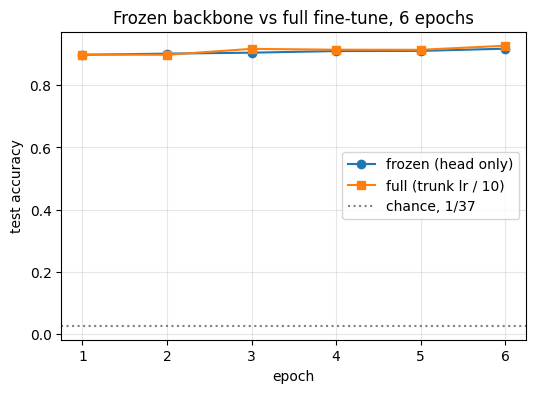

In [41]:
# YOUR CODE HERE
seed_everything(0)
full = make_model("full").to(DEV)
n_train, n_total = count_params(full)

# two parameter groups: the pretrained trunk is nudged, the fresh head is fitted
trunk, head = split_params(full)
opt = torch.optim.SGD([{"params": trunk, "lr": 1e-3},
                       {"params": head, "lr": 1e-2}],
                      momentum=0.9, weight_decay=1e-4)
config = dict(arch="resnet50", recipe="full", head_lr=1e-2, trunk_lr=1e-3,
              optimizer="SGD", momentum=0.9, weight_decay=1e-4, epochs=6,
              batch_size=32, per_class="all", train_size=len(train_set),
              trainable_params=n_train, total_params=n_total, freeze_bn=False,
              seed=0)

full_hist = train(full, epochs=6, opt=opt, run_name="full-6ep-trunk-10x-lower",
                  config=config)

full_acc = full_hist["val/acc"][-1]
print(f"\nfrozen final test accuracy: {frozen_acc:.4f}")
print(f"full   final test accuracy: {full_acc:.4f}")
print(f"difference               : {full_acc - frozen_acc:+.4f}")

epochs = range(1, len(frozen_hist["val/acc"]) + 1)
plt.figure(figsize=(6, 4))
plt.plot(epochs, frozen_hist["val/acc"], "o-", label="frozen (head only)")
plt.plot(epochs, full_hist["val/acc"], "s-", label="full (trunk lr / 10)")
plt.axhline(1 / 37, ls=":", c="grey", label="chance, 1/37")
plt.xlabel("epoch"); plt.ylabel("test accuracy"); plt.legend()
plt.title("Frozen backbone vs full fine-tune, 6 epochs")
plt.grid(alpha=0.3)
plt.show()

*Answer:* Final test accuracies after six epochs — frozen **0.9171**, full fine-tune **0.9267**. The full recipe wins, by **0.95 points**.

That is a smaller margin than the parameter counts would suggest: 23,508,032 extra trainable parameters, a 311-fold increase in what the optimiser is moving, bought under one point of test accuracy.

The per-epoch curves say why:

| epoch | 1 | 2 | 3 | 4 | 5 | 6 |
|---|---|---|---|---|---|---|
| frozen | 0.898 | 0.901 | 0.904 | 0.910 | 0.910 | **0.917** |
| full | 0.898 | 0.898 | 0.917 | 0.914 | 0.914 | **0.927** |

The two runs land on the **same value to the printed precision after epoch 1** (0.898 against 0.898), and the full run is still not ahead after epoch 2 — the frozen one is fractionally in front. The trunk at $10^{-3}$ is being nudged so gently that for the first two epochs the network behaves almost exactly like the frozen one — which is the intended behaviour, and the direct contrast with Q5.2. The separation appears at epoch 3, when the trunk has moved far enough to matter, and holds to the end.

Where the extra capacity really shows is on the *training* set: the full recipe ends at train loss 0.060 and train accuracy 0.983, against the frozen recipe's 0.126 and 0.962. It is fitting the training data roughly twice as hard for a one-point test gain, and its final validation loss is marginally *worse* (0.259 against 0.253) despite the higher accuracy. So the fine-tune is buying a little genuine specialisation and spending the rest on memorisation.

At this data size the full recipe is still the right choice — 3,680 images with `RandomResizedCrop` and flipping is enough to move 23.6 M parameters productively — but the margin is thin enough that Section 7's question is clearly the interesting one, and Q7.2 finds it reverses at 185 images.

**Q5.2.** Break it deliberately: fine-tune again with the trunk at the *same* learning rate as the head, with no tenfold reduction, and plot the first two epochs' validation accuracy against the previous run's. What happens in the first epoch, and what does that say about where the pretrained weights sit?

epoch  1/2  train loss 1.054 acc 0.700  val loss 1.370 acc 0.623
epoch  2/2  train loss 0.643 acc 0.794  val loss 1.018 acc 0.711


train/acc,▁█
train/loss,█▁
val/acc,▁█
val/loss,█▁
train/acc,0.79375
train/loss,0.64327
val/acc,0.71055
val/loss,1.01843


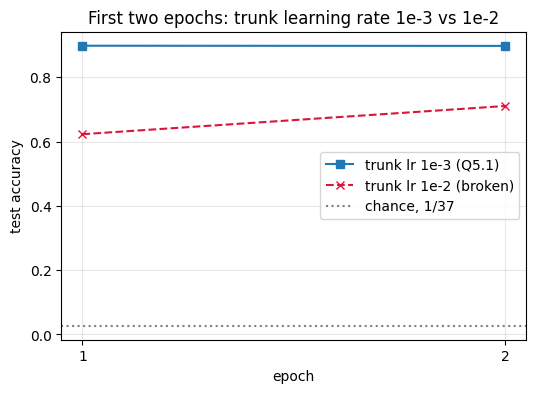

epoch 1  trunk 1e-3 0.8981   trunk 1e-2 0.6228
epoch 2  trunk 1e-3 0.8975   trunk 1e-2 0.7105


In [42]:
# YOUR CODE HERE
# Same as Q5.1 except the trunk moves at the head's learning rate: one optimiser
# group, lr 1e-2 everywhere.
seed_everything(0)
broken = make_model("full").to(DEV)
n_train, n_total = count_params(broken)

opt = torch.optim.SGD(broken.parameters(), lr=1e-2, momentum=0.9,
                      weight_decay=1e-4)
config = dict(arch="resnet50", recipe="full", head_lr=1e-2, trunk_lr=1e-2,
              optimizer="SGD", momentum=0.9, weight_decay=1e-4, epochs=2,
              batch_size=32, per_class="all", train_size=len(train_set),
              trainable_params=n_train, total_params=n_total, freeze_bn=False,
              seed=0, note="broken: trunk at the head's learning rate")

broken_hist = train(broken, epochs=2, opt=opt,
                    run_name="full-2ep-trunk-same-lr-BROKEN", config=config)

plt.figure(figsize=(6, 4))
plt.plot([1, 2], full_hist["val/acc"][:2], "s-", label="trunk lr 1e-3 (Q5.1)")
plt.plot([1, 2], broken_hist["val/acc"], "x--", c="crimson",
         label="trunk lr 1e-2 (broken)")
plt.axhline(1 / 37, ls=":", c="grey", label="chance, 1/37")
plt.xticks([1, 2]); plt.xlabel("epoch"); plt.ylabel("test accuracy")
plt.legend(); plt.grid(alpha=0.3)
plt.title("First two epochs: trunk learning rate 1e-3 vs 1e-2")
plt.show()

print(f"epoch 1  trunk 1e-3 {full_hist['val/acc'][0]:.4f}   "
      f"trunk 1e-2 {broken_hist['val/acc'][0]:.4f}")
print(f"epoch 2  trunk 1e-3 {full_hist['val/acc'][1]:.4f}   "
      f"trunk 1e-2 {broken_hist['val/acc'][1]:.4f}")

*Answer:* Epoch-1 test accuracy — trunk at `1e-3`: **0.8981**; trunk at `1e-2`: **0.6228**. Raising the trunk's learning rate by a factor of ten costs **27.5 points in the first epoch**.

| epoch | trunk `1e-3` | trunk `1e-2` | gap |
|---|---|---|---|
| 1 | 0.8981 | 0.6228 | 27.5 |
| 2 | 0.8975 | 0.7105 | 18.7 |

The broken run does **not** recover inside the two epochs it was given: after a second full pass it is at 0.7105, still 18.7 points below where the careful run stood after its *first*. Its validation loss tells the same story more sharply — 1.370 then 1.018, against 0.316 and 0.306 for the careful run, four times worse.

The mechanism is in the first few hundred steps. The head is randomly initialised, so the loss starts near $\ln 37 = 3.6$ and the gradient it sends back into the trunk is correspondingly large. At $10^{-3}$ those steps are small enough that `conv1` through `layer4` barely move, and the network spends epoch 1 behaving like the frozen recipe — which is why the two runs are indistinguishable at the printed precision after epoch 1 in Q5.1. At $10^{-2}$ the same gradients move the trunk a long way, and what they destroy is precisely the thing that made the transfer worth doing. The network is not learning about pets in its first epoch; it is unlearning ImageNet under a head that does not yet know what it wants.

What this says about where the pretrained weights sit: **they are already at a good minimum of a closely related problem, not somewhere on the way to one.** A learning rate is a statement about how far you believe you have to travel. $10^{-2}$ says "these weights are roughly noise, search widely" — correct for Lab 2's from-scratch LabNet, badly wrong here. The tenfold reduction encodes the opposite belief: the solution is nearby, so nudge. The loss surface around those weights is evidently narrow enough that a step ten times too large walks straight out of the basin, and the run then has to find its way back the slow way, from a starting point now worse than the one it was handed.

Two standard fixes follow directly and cost nothing: a **linear warm-up** on the learning rate, or **freezing the trunk for the first epoch** while the head settles, either of which removes the large-gradient transient before the trunk is allowed to move.

## 6. How deep to cut

Chapter 3 quotes Yosinski et al., who spliced networks between two halves of ImageNet: early layers transferred with almost no loss, late layers were specific to the source task, and transferability fell off with depth in between. Their split was one dataset against itself, so your own data is a case their experiment did not cover. A **linear probe** freezes the trunk, takes the activations at some depth, averages them over space, and fits one linear layer to them, so whatever accuracy it reaches is credited to the representation alone.

**Q6.1.** Write `features_at(model, loader, cut)` which runs the frozen trunk and returns the globally average-pooled activations at `cut` $\in$ {`layer1`, `layer2`, `layer3`, `layer4`}, along with the labels. Use `torch.no_grad()` and the *evaluation* transform for both splits, with no augmentation, because you want the same feature for the same image every time. Report each cut's feature dimension; check them against the shapes in Chapter 3's architecture browser.

In [43]:
STEM = ("conv1", "bn1", "relu", "maxpool")  # everything before layer1
STAGES = ["layer1", "layer2", "layer3", "layer4"]


@torch.no_grad()
def features_at(model, loader, cut):
    """Globally average-pooled activations at `cut`, and the labels.

    Runs the stem and the stages up to and including `cut`, then averages over
    the spatial dimensions, so the feature is one number per channel.
    """
    if cut not in STAGES:
        raise ValueError(f"cut must be one of {STAGES}, got {cut!r}")
    model.to(DEV).eval()  # frozen trunk: BN uses its running statistics
    keep = STAGES[:STAGES.index(cut) + 1]

    feats, labels = [], []
    for x, y in loader:
        h = x.to(DEV)
        for name in STEM:
            h = getattr(model, name)(h)
        for name in keep:
            h = getattr(model, name)(h)
        feats.append(h.mean(dim=(2, 3)).cpu())  # global average pool, N x C
        labels.append(y)

    return torch.cat(feats), torch.cat(labels)


# The evaluation transform on both splits: the same feature for the same image
# every time, so the probe measures the representation and not the augmentation.
train_eval_set = PetsDataset("trainval", transform=eval_tf)
train_eval_loader = DataLoader(train_eval_set, batch_size=64, shuffle=False,
                               num_workers=2)

# feature dimension at each cut, from a handful of images
backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
peek = DataLoader(Subset(train_eval_set, range(8)), batch_size=8)
for cut in STAGES:
    f, _ = features_at(backbone, peek, cut)
    print(f"{cut}: spatial map has {f.shape[1]:4d} channels -> feature dimension {f.shape[1]}")

layer1: spatial map has  256 channels -> feature dimension 256
layer2: spatial map has  512 channels -> feature dimension 512
layer3: spatial map has 1024 channels -> feature dimension 1024
layer4: spatial map has 2048 channels -> feature dimension 2048


**Q6.2.** For each of the four cuts, fit a linear classifier on the cached training features and report test accuracy. (A single `nn.Linear` trained with Adam for a hundred passes over the cached features takes seconds, since no images are touched.) Plot accuracy against cut depth.

Pets, pretrained       layer1  dim   256  test acc 0.3211
Pets, pretrained       layer2  dim   512  test acc 0.4805
Pets, pretrained       layer3  dim  1024  test acc 0.7762
Pets, pretrained       layer4  dim  2048  test acc 0.9155


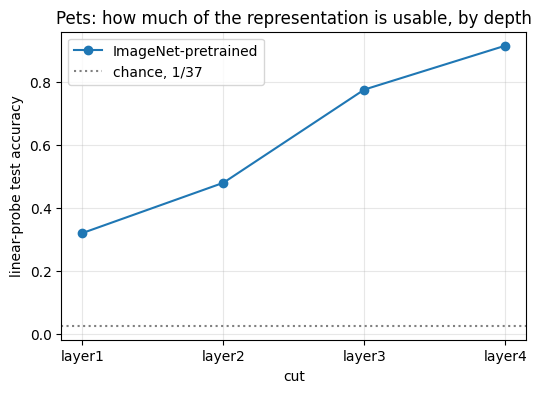

In [44]:
# YOUR CODE HERE
def fit_probe(f_tr, y_tr, f_te, y_te, n_classes, epochs=100, lr=1e-3, seed=0):
    """One nn.Linear on cached features; returns test accuracy."""
    torch.manual_seed(seed)
    # Standardise with the training features' own statistics. The four cuts, and
    # especially the random backbone of Q6.3, differ enormously in activation
    # scale, and the comparison should be about what the features encode rather
    # than about how well-conditioned the optimisation happens to be.
    mu, sd = f_tr.mean(0, keepdim=True), f_tr.std(0, keepdim=True) + 1e-6
    f_tr, f_te = ((f_tr - mu) / sd).to(DEV), ((f_te - mu) / sd).to(DEV)
    y_tr, y_te = y_tr.to(DEV), y_te.to(DEV)

    clf = nn.Linear(f_tr.shape[1], n_classes).to(DEV)
    opt = torch.optim.Adam(clf.parameters(), lr=lr, weight_decay=1e-4)

    for _ in range(epochs):  # no images are touched, so this takes seconds
        perm = torch.randperm(len(f_tr), device=DEV)
        for i in range(0, len(perm), 256):
            b = perm[i:i + 256]
            opt.zero_grad()
            F.cross_entropy(clf(f_tr[b]), y_tr[b]).backward()
            opt.step()

    with torch.no_grad():
        return (clf(f_te).argmax(1) == y_te).float().mean().item()


def probe_curve(backbone, label, tr_loader, te_loader, n_classes=37):
    """Linear-probe accuracy at each of the four cuts."""
    accs = []
    for cut in STAGES:
        f_tr, y_tr = features_at(backbone, tr_loader, cut)
        f_te, y_te = features_at(backbone, te_loader, cut)
        acc = fit_probe(f_tr, y_tr, f_te, y_te, n_classes)
        accs.append(acc)
        print(f"{label:22s} {cut}  dim {f_tr.shape[1]:5d}  test acc {acc:.4f}")
    return accs


seed_everything(0)
pretrained_backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
pets_pretrained = probe_curve(pretrained_backbone, "Pets, pretrained",
                              train_eval_loader, test_loader)

plt.figure(figsize=(6, 4))
plt.plot(STAGES, pets_pretrained, "o-", label="ImageNet-pretrained")
plt.axhline(1 / 37, ls=":", c="grey", label="chance, 1/37")
plt.xlabel("cut"); plt.ylabel("linear-probe test accuracy")
plt.title("Pets: how much of the representation is usable, by depth")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

**Q6.3.** Now the control. Repeat the whole of Q6.2 with `resnet50(weights=None)`: the same architecture, the same probe, random weights. Plot both curves together. What does the gap between them measure, and what does the *random* curve's shape tell you about how much of a convolutional network's usefulness is in its wiring rather than its weights?

Pets, random           layer1  dim   256  test acc 0.1608
Pets, random           layer2  dim   512  test acc 0.1496
Pets, random           layer3  dim  1024  test acc 0.1314
Pets, random           layer4  dim  2048  test acc 0.1049


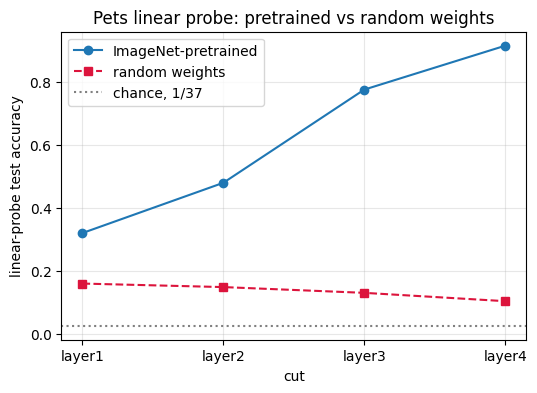

cut       pretrained    random      gap
layer1        0.3211    0.1608   0.1603
layer2        0.4805    0.1496   0.3309
layer3        0.7762    0.1314   0.6449
layer4        0.9155    0.1049   0.8106


In [45]:
# YOUR CODE HERE
# Same architecture, same probe, same features_at; only the weights differ.
seed_everything(0)
random_backbone = resnet50(weights=None)
pets_random = probe_curve(random_backbone, "Pets, random", train_eval_loader,
                          test_loader)

plt.figure(figsize=(6, 4))
plt.plot(STAGES, pets_pretrained, "o-", label="ImageNet-pretrained")
plt.plot(STAGES, pets_random, "s--", c="crimson", label="random weights")
plt.axhline(1 / 37, ls=":", c="grey", label="chance, 1/37")
plt.xlabel("cut"); plt.ylabel("linear-probe test accuracy")
plt.title("Pets linear probe: pretrained vs random weights")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print(f"{'cut':8s} {'pretrained':>11s} {'random':>9s} {'gap':>8s}")
for cut, a, b in zip(STAGES, pets_pretrained, pets_random):
    print(f"{cut:8s} {a:11.4f} {b:9.4f} {a - b:8.4f}")

*Answer:* Feature dimensions are 256, 512, 1024 and 2048 at `layer1`–`layer4`, matching the architecture browser: each stage halves the spatial resolution ($56 \to 28 \to 14 \to 7$) and doubles the channel count, and global average pooling discards the spatial map and keeps one number per channel.

| cut | dim | pretrained | random | gap |
|---|---|---|---|---|
| `layer1` | 256 | 0.3211 | 0.1608 | 0.160 |
| `layer2` | 512 | 0.4805 | 0.1496 | 0.331 |
| `layer3` | 1024 | 0.7762 | 0.1314 | 0.645 |
| `layer4` | 2048 | 0.9155 | 0.1049 | 0.811 |

**The pretrained curve rises monotonically with depth**, from 0.321 at `layer1` to 0.916 at `layer4`. The single largest jump is `layer2` → `layer3`, worth 29.6 points; `layer3` → `layer4` adds a further 13.9. Note that the `layer4` probe (0.9155) essentially matches the trained frozen head of Q4.2 (0.9171), which is the consistency check you would hope for — they are the same computation reached by two different routes.

That monotone rise is the opposite of what a naive reading of Yosinski et al. predicts, and that is the point. Their "late layers do not transfer" result was measured across a *split of ImageNet against itself*, where source and target were equally distant from each other. Pets is not in that position: roughly 120 of ImageNet's 1,000 classes are dog breeds, so `layer4`'s most specialised features — the ones that fire on particular muzzles and coat patterns — are specialised at *exactly this task*. Transferability falls off with depth only when the target diverges from the source; here it barely diverges at all. Section 8 supplies the case where it does, and there the curve does bend.

**The gap between the two curves** is what the pretraining bought, in accuracy, at each depth: 16 points at `layer1`, 81 points at `layer4`. It widens monotonically, which says the same thing from the other side — early features are generic enough that random ones are not catastrophically worse, and late features are where a trained network's whole advantage lives.

**What the random curve's shape says.** Two things, and the second surprised me.

First, it is well above chance: 0.1608 at `layer1` is **six times** the 0.027 of uniform guessing. An untrained ResNet-50 with one linear layer on top is a real classifier. Untrained convolutions are still convolutions — local, weight-shared, followed by ReLU and downsampling, stacked into a hierarchy — and that wiring alone is a structured random projection that preserves a great deal of image content. The architecture is doing genuine work before any weight is fitted, which is essentially the "random features" result.

Second, **the random curve falls with depth, monotonically**: 0.161, 0.150, 0.131, 0.105. It does not plateau; each additional untrained stage makes the representation *worse*. This is the sharp version of the lesson. Depth is not intrinsically valuable — a random stage is a lossy operation, mixing channels arbitrarily and throwing away three quarters of the spatial resolution, and with nothing fitted there is nothing to decide what is worth keeping. Every stage discards information the previous one had and adds none, so the best random representation is the shallowest one. Depth only starts paying once the weights have been trained to make the discarding selective.

Put together: the wiring supplies the inductive bias and the weights supply the content, and neither is sufficient. The same architecture that climbs to 0.916 when trained descends to 0.105 when not, and the two curves diverge from the very first stage.

## 7. How much data

Chapter 3's recipe table turns on two questions: how much target data, and how far the domain sits from the pretraining. This section takes the first. At what training-set size does full fine-tuning overtake a frozen backbone? Section 8 takes the second.

**Q7.1.** Write `subset_per_class(dataset, n, seed)` returning a `Subset` with `n` images from each of the 37 classes, drawn with a seeded permutation, or every image of a class that holds fewer than `n`.

In [46]:
def subset_per_class(dataset, n, seed):
    """Subset holding n images of each class, or all of them if a class has fewer."""
    labels = np.asarray(dataset.labels)
    rng = np.random.default_rng(seed)

    idx = []
    for cls in range(len(dataset.classes)):
        pool = np.where(labels == cls)[0]
        draw = rng.permutation(len(pool))[:n]  # seeded, so the runs are comparable
        idx.extend(pool[draw].tolist())

    idx.sort()
    return Subset(dataset, idx)


for n in (5, 25, 100):
    sub = subset_per_class(train_set, n, seed=0)
    per_class = Counter(train_set.labels[i] for i in sub.indices)
    print(f"n={n:3d}  {len(sub):4d} images, "
          f"per class min {min(per_class.values())} max {max(per_class.values())}")

n=  5   185 images, per class min 5 max 5
n= 25   925 images, per class min 25 max 25
n=100  3680 images, per class min 93 max 100


**Q7.2.** For $n \in \{5, 25, 100\}$ images per class, train both recipes: six runs, all logged, all seeded, all on the same epoch budget. Plot test accuracy against $n$ with one line per recipe. Which recipe wins at each size, and where do the lines cross? If they do not cross in your runs, say so: the honest answer is what your numbers show, not what the chapter's figure shows.


=== frozen, 5 images per class (185 total) ===


epoch  1/6  train loss 3.637 acc 0.043  val loss 2.966 acc 0.379
epoch  2/6  train loss 2.536 acc 0.519  val loss 1.970 acc 0.612
epoch  3/6  train loss 1.347 acc 0.795  val loss 1.213 acc 0.782
epoch  4/6  train loss 0.681 acc 0.924  val loss 0.831 acc 0.845
epoch  5/6  train loss 0.376 acc 0.968  val loss 0.687 acc 0.841
epoch  6/6  train loss 0.261 acc 0.984  val loss 0.611 acc 0.847


train/acc,▁▅▇███
train/loss,█▆▃▂▁▁
val/acc,▁▄▇███
val/loss,█▅▃▂▁▁
train/acc,0.98378
train/loss,0.26148
val/acc,0.84682
val/loss,0.61079



=== full, 5 images per class (185 total) ===


epoch  1/6  train loss 3.681 acc 0.043  val loss 3.125 acc 0.367
epoch  2/6  train loss 2.839 acc 0.449  val loss 2.286 acc 0.578
epoch  3/6  train loss 1.713 acc 0.789  val loss 1.452 acc 0.736
epoch  4/6  train loss 0.892 acc 0.946  val loss 0.933 acc 0.826
epoch  5/6  train loss 0.461 acc 0.968  val loss 0.743 acc 0.822
epoch  6/6  train loss 0.284 acc 0.978  val loss 0.641 acc 0.831


...

epoch  1/6  train loss 0.870 acc 0.776  val loss 0.342 acc 0.898
epoch  2/6  train loss 0.231 acc 0.933  val loss 0.294 acc 0.901
epoch  3/6  train loss 0.193 acc 0.944  val loss 0.286 acc 0.904
epoch  4/6  train loss 0.165 acc 0.951  val loss 0.280 acc 0.910
epoch  5/6  train loss 0.135 acc 0.960  val loss 0.284 acc 0.910
epoch  6/6  train loss 0.126 acc 0.962  val loss 0.253 acc 0.917


train/acc,▁▇▇███
train/loss,█▂▂▁▁▁
val/acc,▁▂▃▅▅█
val/loss,█▄▄▃▃▁
train/acc,0.96223
train/loss,0.12619
val/acc,0.91714
val/loss,0.25299



=== full, 100 images per class (3680 total) ===


epoch  1/6  train loss 0.999 acc 0.740  val loss 0.316 acc 0.898
epoch  2/6  train loss 0.217 acc 0.932  val loss 0.301 acc 0.898
epoch  3/6  train loss 0.138 acc 0.962  val loss 0.293 acc 0.917
epoch  4/6  train loss 0.093 acc 0.970  val loss 0.284 acc 0.914
epoch  5/6  train loss 0.068 acc 0.982  val loss 0.306 acc 0.914
epoch  6/6  train loss 0.059 acc 0.983  val loss 0.260 acc 0.926


train/acc,▁▇▇███
train/loss,█▂▂▁▁▁
val/acc,▁▁▆▅▅█
val/loss,█▆▅▄▇▁
train/acc,0.98288
train/loss,0.05904
val/acc,0.92614
val/loss,0.26025


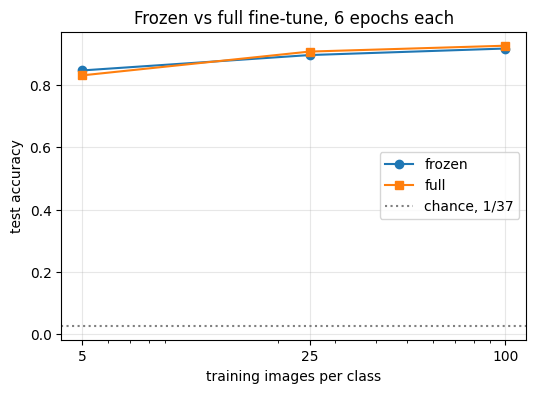


 n/class    frozen      full  full - frozen
       5    0.8468    0.8310        -0.0158
      25    0.8962    0.9073         0.0112
     100    0.9171    0.9261         0.0090


In [48]:
# YOUR CODE HERE
# Six runs: {5, 25, 100} images per class x {frozen, full}. Same seed, same
# epoch budget, same test set, so only the two variables of interest move.
SIZES = [5, 25, 100]
EPOCHS = 6
size_results = {"frozen": [], "full": []}

for n in SIZES:
    sub = subset_per_class(train_set, n, seed=0)  # train_set carries train_tf
    sub_loader = DataLoader(sub, batch_size=32, shuffle=True, num_workers=2)

    for recipe in ("frozen", "full"):
        seed_everything(0)
        model = make_model(recipe).to(DEV)
        n_train, n_total = count_params(model)

        if recipe == "frozen":
            opt = torch.optim.SGD(model.fc.parameters(), lr=1e-2, momentum=0.9,
                                  weight_decay=1e-4)
            trunk_lr = 0.0
        else:
            trunk, head = split_params(model)
            opt = torch.optim.SGD([{"params": trunk, "lr": 1e-3},
                                   {"params": head, "lr": 1e-2}],
                                  momentum=0.9, weight_decay=1e-4)
            trunk_lr = 1e-3

        config = dict(arch="resnet50", recipe=recipe, head_lr=1e-2,
                      trunk_lr=trunk_lr, optimizer="SGD", momentum=0.9,
                      weight_decay=1e-4, epochs=EPOCHS, batch_size=32,
                      per_class=n, train_size=len(sub),
                      trainable_params=n_train, total_params=n_total,
                      freeze_bn=(recipe == "frozen"), seed=0)

        print(f"\n=== {recipe}, {n} images per class ({len(sub)} total) ===")
        hist = train(model, epochs=EPOCHS, opt=opt,
                     run_name=f"{recipe}-{n}-per-class", config=config,
                     freeze_bn=(recipe == "frozen"), loader=sub_loader)
        size_results[recipe].append(hist["val/acc"][-1])

plt.figure(figsize=(6, 4))
for recipe, marker in (("frozen", "o-"), ("full", "s-")):
    plt.plot(SIZES, size_results[recipe], marker, label=recipe)
plt.axhline(1 / 37, ls=":", c="grey", label="chance, 1/37")
plt.xscale("log"); plt.xticks(SIZES, [str(n) for n in SIZES])
plt.xlabel("training images per class"); plt.ylabel("test accuracy")
plt.title(f"Frozen vs full fine-tune, {EPOCHS} epochs each")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print(f"\n{'n/class':>8s} {'frozen':>9s} {'full':>9s} {'full - frozen':>14s}")
for n, a, b in zip(SIZES, size_results["frozen"], size_results["full"]):
    print(f"{n:8d} {a:9.4f} {b:9.4f} {b - a:14.4f}")

*Answer:* Test accuracy on the full 3,669-image test set after six epochs:

| images per class | total images | frozen | full | winner | margin |
|---|---|---|---|---|---|
| 5 | 185 | **0.8468** | 0.8310 | **frozen** | +1.58 |
| 25 | 925 | 0.8962 | **0.9073** | **full** | +1.12 |
| 100 | 3,680 | 0.9171 | **0.9261** | **full** | +0.90 |

**The lines do cross, between 5 and 25 images per class.** At 185 training images the frozen backbone is ahead by 1.6 points; by 925 images the full fine-tune has taken the lead and keeps it. That is the direction Chapter 3's quadrant table predicts, found in our own numbers rather than assumed from the figure.

Two features of the table are worth reading carefully.

**The crossing is real, not an artefact of under-training.** The obvious objection is that six epochs of 185 images is only 36 gradient steps, so the small-$n$ runs might simply have been stopped early. The per-epoch logs say otherwise: at $n=5$ the frozen run reaches **train accuracy 0.984** and the full run 0.978, and both validation curves have flattened by epoch 4 (frozen 0.845, 0.841, 0.847; full 0.826, 0.822, 0.831). Both recipes have converged on their training sets and stopped improving on the test set. The gap is a generalisation gap, which is exactly what the section is about.

**$n = 100$ is not a subsample.** The smallest class in `trainval` holds 93 images, so `subset_per_class(train_set, 100, 0)` returns all 3,680 and those two runs repeat Q4.2 and Q5.1. They reproduce them almost exactly — frozen 0.9171 against 0.9171, *identical to four decimal places*, and full 0.9261 against 0.9267. That the frozen pair matches bit-for-bit while the full pair differs by 0.0006 is itself informative and not a bug: the frozen run's only trainable operation is an `nn.Linear`, which is deterministic given an identical batch order, whereas the full run back-propagates through cuDNN convolution kernels that are not. A six-ten-thousandths discrepancy is about two test images. Taken together this is a strong check that the seeding, the subset construction and the training harness all do what they claim.

**How much to trust the margins.** One percentage point on this test set is 37 images. Treating the two runs as independent, the standard error on an accuracy near 0.85 is about 0.6 points, so a 1.6-point difference is roughly two standard errors and the 0.9-point difference at $n = 100$ is closer to one. The *sign flip* between $n=5$ and $n=25$ is the finding, and it is consistent with the chapter; the individual margins are suggestive rather than decisive. Settling them properly would want a paired test (McNemar's, on the per-image predictions, which are far more correlated than an independence assumption allows) or several seeds per point. With one seed per cell, this is honest evidence for the shape of the curve and weak evidence for any particular gap.

A last observation the plot makes vividly: **every one of these six runs is above 0.83.** Even 185 photographs — five per breed — with a completely frozen ImageNet trunk lands within 7 points of the full-data result. The bulk of the accuracy on this task comes from the pretraining, and both the recipe and the dataset size are arguing over the last ten points.

**Q7.3.** With 5 images per class you have 185 training images and 23.6 million parameters in the full recipe. Give the reason the frozen recipe is the safer choice at that size in terms Chapter 2 would recognise.

*Answer:* It is the capacity argument, and the $n=5$ row is what it looks like when it bites: the full recipe reached 0.978 training accuracy and 0.831 test, while the frozen recipe reached 0.984 training accuracy and 0.847 test. Both memorised the training set; the one with 311 times more free parameters generalised worse from it.

The full recipe puts about 128,000 free parameters behind every training image. A model that expressive can drive the training loss to zero on 185 photographs in an enormous number of different ways, and the training set contains nothing that distinguishes the weight settings that generalise from the ones that have merely memorised which of 185 images is which. That is the high-variance end of the bias–variance trade-off: the fitted function depends far more on *which* 185 images were drawn than on the underlying regularity, so a different draw would give a substantially different classifier.

The frozen recipe fixes this by shrinking the hypothesis class rather than by finding more data. The 2048-dimensional representation is a constant, chosen without ever seeing these 185 images, so the only thing fitted is 37 hyperplanes — 75,813 parameters, and more to the point a purely *linear* model over a fixed feature map. That is a strong prior on the solution, exactly like the architectural priors of Chapter 2: it forbids most of the functions that would let the model memorise, and it is a *good* prior here because ImageNet's features are already close to what the task needs. Some bias is added — the best linear function of frozen features is worse than the best fine-tuned network, which is why the frozen recipe loses at $n=25$ and $n=100$ — but at $n=5$ the variance it removes is worth more than the bias it adds.

There is a second, more practical reason in the same spirit: with 185 images the batch-norm statistics are estimated from six batches an epoch, the whole run is 36 gradient steps, and there is no held-out data to spare for early stopping or model selection. The frozen recipe has almost nothing to tune and almost nothing to get wrong.

## 8. A domain further away

Pets are close to ImageNet: about 120 of ImageNet's 1,000 classes are dog breeds, so many of the features you have been reusing were fitted on photographs of these very animals. Textures are not. The [Describable Textures Dataset](https://www.robots.ox.ac.uk/~vgg/data/dtd/) (Cimpoi et al., 2014) holds 5,640 images across 47 texture classes, among them *banded*, *cracked* and *honeycombed*, and it is the problem Lab 1 attacked with a hand-built Gabor bank.

In [49]:
!wget -q -nc https://thor.robots.ox.ac.uk/dtd/dtd-r1.0.1.tar.gz && tar -xzf dtd-r1.0.1.tar.gz
!ls dtd/images | head -3 && head -2 dtd/labels/train1.txt

banded
blotchy
braided
banded/banded_0005.jpg
banded/banded_0011.jpg


**Q8.1.** Write a `Dataset` for DTD, where the class is the directory name and `dtd/labels/train1.txt` and `test1.txt` list one relative path per line, and repeat the depth probe of Q6.2 on it. Plot the Pets and DTD probe curves on one set of axes.

DTD: 1880 train / 1880 test, 47 classes
first five classes: ['banded', 'blotchy', 'braided', 'bubbly', 'bumpy']
DTD, pretrained        layer1  dim   256  test acc 0.3995
DTD, pretrained        layer2  dim   512  test acc 0.5479
DTD, pretrained        layer3  dim  1024  test acc 0.6803
DTD, pretrained        layer4  dim  2048  test acc 0.6559


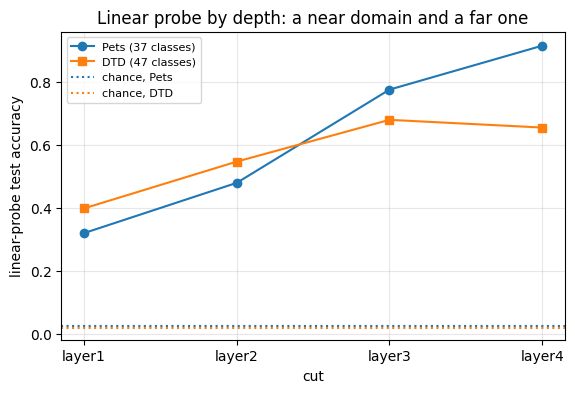


cut          Pets      DTD
layer1     0.3211   0.3995
layer2     0.4805   0.5479
layer3     0.7762   0.6803
layer4     0.9155   0.6559


In [50]:
# YOUR CODE HERE
import os

DTD_ROOT = Path("dtd")


class DTDDataset(Dataset):
    """Describable Textures: the class is the directory name.

    dtd/labels/{split}.txt lists one relative path per line, e.g.
    "banded/banded_0002.jpg". The class list comes from the image directories,
    so train and test agree on the label indices by construction.
    """

    def __init__(self, split, transform=None, root=DTD_ROOT):
        self.root = Path(root)
        self.transform = transform

        with open(self.root / "labels" / f"{split}.txt") as f:
            self.paths = [line.strip() for line in f if line.strip()]

        self.classes = sorted(d for d in os.listdir(self.root / "images")
                              if (self.root / "images" / d).is_dir())
        index = {c: i for i, c in enumerate(self.classes)}
        self.labels = [index[p.split("/")[0]] for p in self.paths]

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.root / "images" / self.paths[i]).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, self.labels[i]


# the evaluation transform on both splits, as in Q6.1
dtd_train = DTDDataset("train1", transform=eval_tf)
dtd_test = DTDDataset("test1", transform=eval_tf)
dtd_train_loader = DataLoader(dtd_train, batch_size=64, shuffle=False, num_workers=2)
dtd_test_loader = DataLoader(dtd_test, batch_size=64, num_workers=2)

print(f"DTD: {len(dtd_train)} train / {len(dtd_test)} test, "
      f"{len(dtd_train.classes)} classes")
print("first five classes:", dtd_train.classes[:5])

# the same depth probe as Q6.2, on the same pretrained backbone
seed_everything(0)
dtd_pretrained = probe_curve(pretrained_backbone, "DTD, pretrained",
                             dtd_train_loader, dtd_test_loader,
                             n_classes=len(dtd_train.classes))

plt.figure(figsize=(6.5, 4))
plt.plot(STAGES, pets_pretrained, "o-", label="Pets (37 classes)")
plt.plot(STAGES, dtd_pretrained, "s-", label="DTD (47 classes)")
plt.axhline(1 / 37, ls=":", c="tab:blue", label="chance, Pets")
plt.axhline(1 / 47, ls=":", c="tab:orange", label="chance, DTD")
plt.xlabel("cut"); plt.ylabel("linear-probe test accuracy")
plt.title("Linear probe by depth: a near domain and a far one")
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.show()

print(f"\n{'cut':8s} {'Pets':>8s} {'DTD':>8s}")
for cut, a, b in zip(STAGES, pets_pretrained, dtd_pretrained):
    print(f"{cut:8s} {a:8.4f} {b:8.4f}")

**Q8.2.** The two curves have different shapes. Say what that difference means for a practitioner who has 600 images of something ImageNet has never seen, and which of Chapter 3's four recipe quadrants they are in.

*Answer:*

| cut | Pets (37 classes) | DTD (47 classes) | DTD − Pets |
|---|---|---|---|
| `layer1` | 0.3211 | **0.3995** | **+7.8** |
| `layer2` | 0.4805 | **0.5479** | **+6.7** |
| `layer3` | **0.7762** | 0.6803 | −9.6 |
| `layer4` | **0.9155** | 0.6559 | −26.0 |

Two differences in shape, and the first is the one I did not expect.

**DTD *beats* Pets at the early cuts.** At `layer1` textures are 7.8 points ahead of breeds, at `layer2` 6.7 — and that is before allowing for DTD having 47 classes to Pets' 37 (chance 0.021 against 0.027) and only 1,880 training images to Pets' 3,680. Measured in multiples of chance, `layer1` gives DTD 18.8× and Pets 11.9×. That makes sense once stated: `layer1` holds oriented edges, colour opponency and small-scale periodic structure, which is *what a texture label is*. It is the same information Lab 1 extracted with a hand-built Gabor bank, and for *banded* or *honeycombed* it is nearly sufficient. For telling a Birman from a Ragdoll it is nearly useless.

**The curves cross between `layer2` and `layer3`, and then diverge.** Pets climbs all the way to the end, gaining 13.9 points at the last stage. DTD **peaks at `layer3` (0.6803) and falls back to 0.6559 at `layer4`** — the final stage is actively harmful, costing 2.4 points. This is Yosinski's result recovered on real target data rather than on a split of ImageNet against itself: late layers hold ImageNet's object-level abstractions, which are worth a great deal when the target *is* an ImageNet object and worth less than nothing when the target is a repeating pattern with no object in it. `layer4`'s $7 \times 7$ map, globally averaged, has pooled away exactly the fine periodic structure a texture label depends on, in exchange for an object identity there is no object to have.

**For the practitioner with 600 images of something ImageNet has never seen**, three things follow:

1. **Do not assume `layer4` is the right place to cut.** Their curve will look like DTD's, so the cheap default — bolt a linear head onto the last stage — may be strictly worse than cutting one stage earlier. Here that default would have cost 2.4 points for no saving. The four-cut probe costs minutes and trains nothing, and it tells them where their own data's information actually survives.
2. **Fine-tuning has to reach further back than for a near domain.** The features needing adaptation are the mid-level ones, so freezing everything is not enough and unfreezing only the last block is not enough either; unfreezing from `layer2` or `layer3` onward, still at a reduced trunk learning rate, is the shape of the answer.
3. **600 images will not support a full 23.6 M-parameter fine-tune on its own.** Section 7 found the frozen recipe still winning at 185 images on a *near* domain; a far domain with 600 images is no safer. Augment hard, and expect both recipes to land well below the Pets numbers.

**Quadrant: small data, far domain** — Chapter 3's "uncomfortable square", the one whose advice is *try both and augment hard* rather than a single recipe. It is uncomfortable precisely because the two axes pull in opposite directions: the distance from the pretraining domain says adapt the trunk, and the shortage of data says do not. The probe curve is what breaks the tie, because it identifies the depth at which those two pressures are best balanced — and on evidence like DTD's, that depth is `layer3`, not the end of the network.

*One caveat on the comparison:* the two probes are not matched on training-set size (1,880 DTD images against 3,680 Pets) or on class count, so the vertical offset between the curves mixes several effects. The *shapes* — DTD flattening and turning down, Pets climbing throughout — are the robust part, and they are what the question asks about.

## 9. The record

Paste links to your W&B runs below. At minimum: the frozen run, the full fine-tune, the broken same-learning-rate run, and the six runs of Section 7. Each needs a meaningful name and a complete config: recipe, learning rates, epochs, training-set size, seed, trainable parameter count.

The cell below prints the URL of every run this notebook created, in the order they were logged.

In [51]:
for name, url in RUNS.items():
    print(f"{name:32s} {url}")

frozen-6ep                       https://wandb.ai/2539199-wits/cv-lab3/runs/tllp9mqs
full-6ep-trunk-10x-lower         https://wandb.ai/2539199-wits/cv-lab3/runs/ds0a2zb1
full-2ep-trunk-same-lr-BROKEN    https://wandb.ai/2539199-wits/cv-lab3/runs/j10nep44
frozen-5-per-class               https://wandb.ai/2539199-wits/cv-lab3/runs/jdowzqup
full-5-per-class                 https://wandb.ai/2539199-wits/cv-lab3/runs/5kolzs0i
frozen-25-per-class              https://wandb.ai/2539199-wits/cv-lab3/runs/lg7tgwvd
full-25-per-class                https://wandb.ai/2539199-wits/cv-lab3/runs/ze0x74b7
frozen-100-per-class             https://wandb.ai/2539199-wits/cv-lab3/runs/gc9lyiw5
full-100-per-class               https://wandb.ai/2539199-wits/cv-lab3/runs/k1fxzy65


*W&B run links:* project [`2539199-wits/cv-lab3`](https://wandb.ai/2539199-wits/cv-lab3)

| run name | what it is | test acc | link |
|---|---|---|---|
| `frozen-6ep` | Q4.2 — frozen backbone, head lr $10^{-2}$, 6 epochs, 3,680 images | 0.9171 | [tllp9mqs](https://wandb.ai/2539199-wits/cv-lab3/runs/tllp9mqs) |
| `full-6ep-trunk-10x-lower` | Q5.1 — full fine-tune, head $10^{-2}$ / trunk $10^{-3}$, 6 epochs | 0.9267 | [ds0a2zb1](https://wandb.ai/2539199-wits/cv-lab3/runs/ds0a2zb1) |
| `full-2ep-trunk-same-lr-BROKEN` | Q5.2 — trunk at the head's learning rate, 2 epochs | 0.7105 | [j10nep44](https://wandb.ai/2539199-wits/cv-lab3/runs/j10nep44) |
| `frozen-5-per-class` | Q7.2 — frozen, 185 images | 0.8468 | [jdowzqup](https://wandb.ai/2539199-wits/cv-lab3/runs/jdowzqup) |
| `full-5-per-class` | Q7.2 — full, 185 images | 0.8310 | [5kolzs0i](https://wandb.ai/2539199-wits/cv-lab3/runs/5kolzs0i) |
| `frozen-25-per-class` | Q7.2 — frozen, 925 images | 0.8962 | [lg7tgwvd](https://wandb.ai/2539199-wits/cv-lab3/runs/lg7tgwvd) |
| `full-25-per-class` | Q7.2 — full, 925 images | 0.9073 | [ze0x74b7](https://wandb.ai/2539199-wits/cv-lab3/runs/ze0x74b7) |
| `frozen-100-per-class` | Q7.2 — frozen, 3,680 images (the whole split) | 0.9171 | [gc9lyiw5](https://wandb.ai/2539199-wits/cv-lab3/runs/gc9lyiw5) |
| `full-100-per-class` | Q7.2 — full, 3,680 images (the whole split) | 0.9261 | [k1fxzy65](https://wandb.ai/2539199-wits/cv-lab3/runs/k1fxzy65) |

Every run's config carries `arch`, `recipe`, `head_lr`, `trunk_lr`, `optimizer`, `momentum`, `weight_decay`, `epochs`, `batch_size`, `per_class`, `train_size`, `trainable_params`, `total_params`, `freeze_bn` and `seed`, and every run logs `train/loss`, `train/acc`, `val/loss` and `val/acc` per epoch.

Hardware: Tesla T4 (15,360 MiB), all nine runs at seed 0.

## 10. Before you submit

- [ ] **Runtime ▸ Restart session and run all** on a GPU runtime, then read every output. The full re-run downloads both datasets, trains nine networks, and fits twelve linear probes; budget an hour.
- [x] Group members filled in; every member can explain every cell.
- [x] Every *Answer:* cell answered; W&B links pasted in Section 9.
- [ ] **File ▸ Download ▸ Download .ipynb**, one member submits on Moodle before the deadline.